In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [2]:
data_root = "confirmed_fronts"

all_images = glob.glob(os.path.join(data_root, "**", "*.jpg"), recursive=True)
print(f"Total images: {len(all_images)}")

image_paths = []
labels = []

for path in all_images:
    filename = os.path.basename(path)
    parts = filename.split("$$")
    if len(parts) >= 4:
        color = parts[3]
        image_paths.append(path)
        labels.append(color)

color_counts = Counter(labels)
print(f"\nClass count: {len(color_counts)}")
print("\nColor distribution:")
for color, count in color_counts.most_common():
    print(f"  {color}: {count}")

Total images: 61827

Class count: 23

Color distribution:
  Black: 14317
  Grey: 9474
  White: 9395
  Blue: 8483
  Silver: 7770
  Red: 6095
  Unlisted: 1516
  Brown: 911
  Green: 777
  Yellow: 667
  Beige: 600
  Orange: 559
  Purple: 362
  Bronze: 329
  Gold: 217
  Multicolour: 196
  Pink: 87
  Maroon: 26
  Turquoise: 26
  Magenta: 9
  Burgundy: 9
  Indigo: 1
  Navy: 1


In [3]:
MIN_SAMPLES = 80

filtered_colors = {c for c, cnt in color_counts.items() if cnt >= MIN_SAMPLES} - {'Unlisted', 'Multicolour'}
print(f"After filer (>= {MIN_SAMPLES} examples): {sorted(filtered_colors)}")

filtered_paths = []
filtered_labels = []
for p, l in zip(image_paths, labels):
    if l in filtered_colors:
        filtered_paths.append(p)
        filtered_labels.append(l)

print(f"After filter: {len(filtered_paths)}")

color_to_idx = {c: i for i, c in enumerate(sorted(filtered_colors))}
idx_to_color = {i: c for c, i in color_to_idx.items()}
num_classes = len(color_to_idx)
print(f"\nColor mapping: {color_to_idx}")

After filer (>= 80 examples): ['Beige', 'Black', 'Blue', 'Bronze', 'Brown', 'Gold', 'Green', 'Grey', 'Orange', 'Pink', 'Purple', 'Red', 'Silver', 'White', 'Yellow']
After filter: 60043

Color mapping: {'Beige': 0, 'Black': 1, 'Blue': 2, 'Bronze': 3, 'Brown': 4, 'Gold': 5, 'Green': 6, 'Grey': 7, 'Orange': 8, 'Pink': 9, 'Purple': 10, 'Red': 11, 'Silver': 12, 'White': 13, 'Yellow': 14}


In [4]:
class CarColorDataset(Dataset):
    def __init__(self, image_paths, labels, color_to_idx, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.color_to_idx = color_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.color_to_idx[self.labels[idx]]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [5]:
from dataset import CarColorDataset

In [19]:
train_transform = transforms.Compose([
    transforms.RandomResizeCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

combined = list(zip(filtered_paths, filtered_labels))
random.shuffle(combined)
shuffled_paths, shuffled_labels = zip(*combined)
shuffled_paths = list(shuffled_paths)
shuffled_labels = list(shuffled_labels)

n = len(shuffled_paths)
n_train = int(0.7 * n)
n_val = int(0.15 * n)

train_paths, train_labels = shuffled_paths[:n_train], shuffled_labels[:n_train]
val_paths, val_labels = shuffled_paths[n_train:n_train + n_val], shuffled_labels[n_train:n_train + n_val]
test_paths, test_labels = shuffled_paths[n_train + n_val:], shuffled_labels[n_train + n_val:]

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

train_dataset = CarColorDataset(train_paths, train_labels, color_to_idx, train_transform)
val_dataset = CarColorDataset(val_paths, val_labels, color_to_idx, val_transform)
test_dataset = CarColorDataset(test_paths, test_labels, color_to_idx, val_transform)

Train: 42030, Val: 9006, Test: 9007


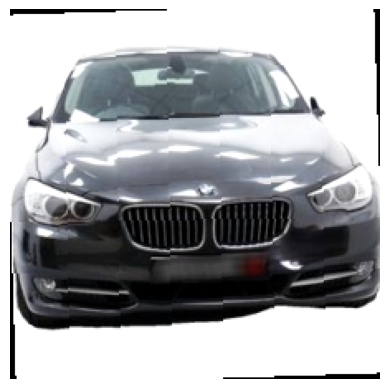

In [67]:
img, label = train_dataset[0]


def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img * std + mean


img = unnormalize(img)
img = img.permute(1, 2, 0)
img = img.numpy()
img = np.clip(img, 0, 1)

plt.imshow(img)
plt.axis("off")
plt.show()

In [7]:
label_indices = [color_to_idx[l] for l in train_labels]
class_counts = Counter(label_indices)
total = sum(class_counts.values())
class_weights = torch.zeros(num_classes)
for cls_idx, count in class_counts.items():
    class_weights[cls_idx] = total / (num_classes * count)

class_weights = class_weights.to(device)
print(f"Class weights: {class_weights}")

Class weights: tensor([ 6.6556,  0.2783,  0.4728, 12.3436,  4.3108, 17.4037,  5.0486,  0.4231,
         7.3159, 47.4915, 11.1633,  0.6574,  0.5122,  0.4301,  6.1313],
       device='mps:0')


In [20]:
BATCH_SIZE = 32
num_workers = 12


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)

In [9]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


class MyResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(MyResNet18, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        self._initialize_weights()

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        layers = [BasicBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


model_custom = MyResNet18(num_classes=num_classes).to(device)
print(f"MyResNet18 params: {sum(p.numel() for p in model_custom.parameters()):,}")

MyResNet18 params: 11,184,207


In [10]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0
    total = 0
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            total += labels.size(0)
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return running_loss / total, acc, f1, all_labels, all_preds


def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, model_name="model"):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

    best_f1 = 0.0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)
        scheduler.step(val_f1)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1_macro: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), f"best_{model_name}.pth")

    model.load_state_dict(torch.load(f"best_{model_name}.pth", weights_only=True))
    print(f"\nBest Val F1_macro for {model_name}: {best_f1:.4f}")
    return history

In [24]:
model_custom.load_state_dict(torch.load(f"best_MyResNet18f.pth", weights_only=True))

<All keys matched successfully>

In [25]:
history_custom = train_model(model_custom, train_loader, val_loader,
                             epochs=25, lr=1e-3, model_name="MyResNet18")

[MyResNet18] Epoch 1/25 | Train Loss: 0.6027 Acc: 0.8445 | Val Loss: 0.3958 Acc: 0.9030 F1_macro: 0.7843


[MyResNet18] Epoch 2/25 | Train Loss: 0.5077 Acc: 0.8497 | Val Loss: 0.4588 Acc: 0.8656 F1_macro: 0.7102


[MyResNet18] Epoch 3/25 | Train Loss: 0.4712 Acc: 0.8565 | Val Loss: 0.4898 Acc: 0.8795 F1_macro: 0.7573


[MyResNet18] Epoch 4/25 | Train Loss: 0.4409 Acc: 0.8598 | Val Loss: 0.5345 Acc: 0.8614 F1_macro: 0.7229


[MyResNet18] Epoch 5/25 | Train Loss: 0.4308 Acc: 0.8611 | Val Loss: 0.6109 Acc: 0.8197 F1_macro: 0.6768


...

[MyResNet18] Epoch 7/25 | Train Loss: 0.2568 Acc: 0.9010 | Val Loss: 0.4971 Acc: 0.9013 F1_macro: 0.7985


[MyResNet18] Epoch 8/25 | Train Loss: 0.2266 Acc: 0.9082 | Val Loss: 0.4482 Acc: 0.9050 F1_macro: 0.7941


[MyResNet18] Epoch 9/25 | Train Loss: 0.2260 Acc: 0.9096 | Val Loss: 0.4814 Acc: 0.9141 F1_macro: 0.8136


[MyResNet18] Epoch 10/25 | Train Loss: 0.2183 Acc: 0.9090 | Val Loss: 0.4239 Acc: 0.9117 F1_macro: 0.8213


KeyboardInterrupt: 

In [68]:
test_loss, test_acc, test_f1, true_labels, pred_labels = evaluate(model_custom, test_loader)
test_loss, test_acc, test_f1

(0.5108328004115044, np.float64(0.896524925058288), 0.77276299136941)

In [11]:
model_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model_resnet50.parameters():
    param.requires_grad = False

for param in model_resnet50.layer4.parameters():
    param.requires_grad = True

model_resnet50.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model_resnet50.fc.in_features, num_classes)
)

model_resnet50 = model_resnet50.to(device)
print(f"ResNet50 learnable params "
      f"{sum(p.numel() for p in model_resnet50.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/bogdan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:35<00:00, 2.89MB/s]


ResNet50 learnable params14,995,471


In [69]:
history_resnet50 = train_model(model_resnet50, train_loader, val_loader,
                               epochs=15, lr=1e-3, model_name="ResNet50_pretrained")

Training:  43%|█████████████████████████████████████████████████▉                                                                 | 570/1314 [01:40<02:03,  6.02it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x10ace1c10>
Traceback (most recent call last):
  File "/Users/bogdan/Developer/ai-venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/Users/bogdan/Developer/ai-venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1628, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentin

KeyboardInterrupt: 

In [12]:
model_effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

for param in model_effnet.parameters():
    param.requires_grad = False

for param in model_effnet.features[-3:].parameters():
    param.requires_grad = True

model_effnet.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model_effnet.classifier[1].in_features, num_classes)
)

model_effnet = model_effnet.to(device, non_blocking=True)
print(f"EfficientNet-B0 learnable params: "
      f"{sum(p.numel() for p in model_effnet.parameters() if p.requires_grad):,}")

EfficientNet-B0 learnable params: 3,174,955


In [14]:
model_effnet.load_state_dict(torch.load(f"best_EffNet_pretrained.pth", weights_only=True))

<All keys matched successfully>

In [21]:
history_effnet = train_model(model_effnet, train_loader, val_loader,
                             epochs=15, lr=1e-3, model_name="EffNet_pretrained")

[EffNet_pretrained] Epoch 1/20 | Train Loss: 0.3746 Acc: 0.8909 | Val Loss: 0.2740 Acc: 0.9145 F1_macro: 0.8321


[EffNet_pretrained] Epoch 2/20 | Train Loss: 0.2704 Acc: 0.8968 | Val Loss: 0.2764 Acc: 0.9167 F1_macro: 0.8348


[EffNet_pretrained] Epoch 3/20 | Train Loss: 0.2375 Acc: 0.9038 | Val Loss: 0.2989 Acc: 0.9206 F1_macro: 0.8525


[EffNet_pretrained] Epoch 4/20 | Train Loss: 0.2247 Acc: 0.9103 | Val Loss: 0.3224 Acc: 0.9295 F1_macro: 0.8692


[EffNet_pretrained] Epoch 5/20 | Train Loss: 0.1960 Acc: 0.9140 | Val Loss: 0.3622 Acc: 0.9289 F1_macro: 0.8761


...

[EffNet_pretrained] Epoch 10/20 | Train Loss: 0.1402 Acc: 0.9304 | Val Loss: 0.3057 Acc: 0.9289 F1_macro: 0.8763


[EffNet_pretrained] Epoch 11/20 | Train Loss: 0.1212 Acc: 0.9355 | Val Loss: 0.3197 Acc: 0.9292 F1_macro: 0.8688


[EffNet_pretrained] Epoch 12/20 | Train Loss: 0.1168 Acc: 0.9392 | Val Loss: 0.3529 Acc: 0.9329 F1_macro: 0.8831


Training:  35%|████████████████████████████████████████▏                                                                          | 459/1314 [00:43<01:07, 12.71it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x10ace1c10>
Traceback (most recent call last):
  File "/Users/bogdan/Developer/ai-venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/Users/bogdan/Developer/ai-venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1628, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentin

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc, test_f1, true_labels, pred_labels = evaluate(model_effnet, test_loader)
test_loss, test_acc, test_f1

In [31]:
results = {}

models_dict = {
    "MyResNet18 (from scratch)": model_custom,
    "ResNet50 (pretrained)": model_resnet50,
    "EfficientNet-B0 (pretrained)": model_effnet,
}

for name, model in models_dict.items():
    test_loss, test_acc, test_f1, true_labels, pred_labels = evaluate(model, test_loader)
    results[name] = {
        "accuracy": test_acc,
        "f1_macro": test_f1,
        "true": true_labels,
        "pred": pred_labels
    }
    print(f"\n{'=' * 60}")
    print(f"Model: {name}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test F1_macro: {test_f1:.4f}")
    print(f"\nClassification Report:")
    target_names = [idx_to_color[i] for i in range(num_classes)]
    print(classification_report(true_labels, pred_labels, target_names=target_names))


Model: MyResNet18 (from scratch)
Test Accuracy: 0.8965
Test F1_macro: 0.7728

Classification Report:
              precision    recall  f1-score   support

       Beige       0.73      0.79      0.76        86
       Black       0.96      0.85      0.90      2170
        Blue       0.90      0.93      0.91      1258
      Bronze       0.42      0.65      0.51        43
       Brown       0.46      0.81      0.59       123
        Gold       0.37      0.59      0.46        27
       Green       0.59      0.88      0.71       103
        Grey       0.87      0.85      0.86      1409
      Orange       0.70      0.90      0.79        90
        Pink       0.54      0.87      0.67        15
      Purple       0.56      0.78      0.65        63
         Red       0.97      0.93      0.95       875
      Silver       0.90      0.92      0.91      1196
       White       0.97      0.97      0.97      1449
      Yellow       0.95      0.96      0.96       100

    accuracy                    


Model: ResNet50 (pretrained)
Test Accuracy: 0.8903
Test F1_macro: 0.7610

Classification Report:
              precision    recall  f1-score   support

       Beige       0.82      0.57      0.67        86
       Black       0.91      0.93      0.92      2170
        Blue       0.92      0.87      0.89      1258
      Bronze       0.34      0.70      0.46        43
       Brown       0.50      0.54      0.52       123
        Gold       0.47      0.63      0.54        27
       Green       0.62      0.78      0.69       103
        Grey       0.85      0.81      0.83      1409
      Orange       0.86      0.83      0.85        90
        Pink       0.71      0.80      0.75        15
      Purple       0.67      0.46      0.55        63
         Red       0.97      0.96      0.97       875
      Silver       0.89      0.89      0.89      1196
       White       0.95      0.97      0.96      1449
      Yellow       0.92      0.95      0.94       100

    accuracy                        


Model: EfficientNet-B0 (pretrained)
Test Accuracy: 0.9379
Test F1_macro: 0.8812

Classification Report:
              precision    recall  f1-score   support

       Beige       0.86      0.95      0.91        86
       Black       0.97      0.93      0.95      2170
        Blue       0.95      0.94      0.95      1258
      Bronze       0.73      0.74      0.74        43
       Brown       0.70      0.86      0.77       123
        Gold       0.77      0.89      0.83        27
       Green       0.80      0.95      0.87       103
        Grey       0.89      0.92      0.90      1409
      Orange       0.82      0.97      0.89        90
        Pink       0.62      0.87      0.72        15
      Purple       0.82      0.86      0.84        63
         Red       0.99      0.96      0.97       875
      Silver       0.93      0.93      0.93      1196
       White       0.98      0.98      0.98      1449
      Yellow       0.98      0.99      0.99       100

    accuracy                 

                       Model  Accuracy  F1_macro
EfficientNet-B0 (pretrained)  0.937937  0.881246
   MyResNet18 (from scratch)  0.896525  0.772763
       ResNet50 (pretrained)  0.890308  0.761032


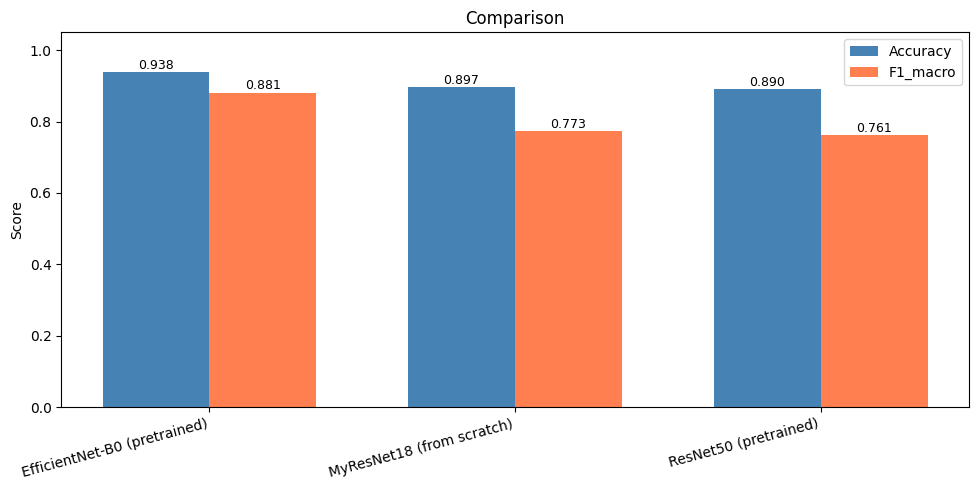

In [32]:
comparison = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[k]["accuracy"] for k in results],
    "F1_macro": [results[k]["f1_macro"] for k in results],
})

comparison = comparison.sort_values("F1_macro", ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.35
bars1 = ax.bar(x - width/2, comparison["Accuracy"], width, label="Accuracy", color="steelblue")
bars2 = ax.bar(x + width/2, comparison["F1_macro"], width, label="F1_macro", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Comparison")
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("comparison.png", dpi=150)
plt.show()

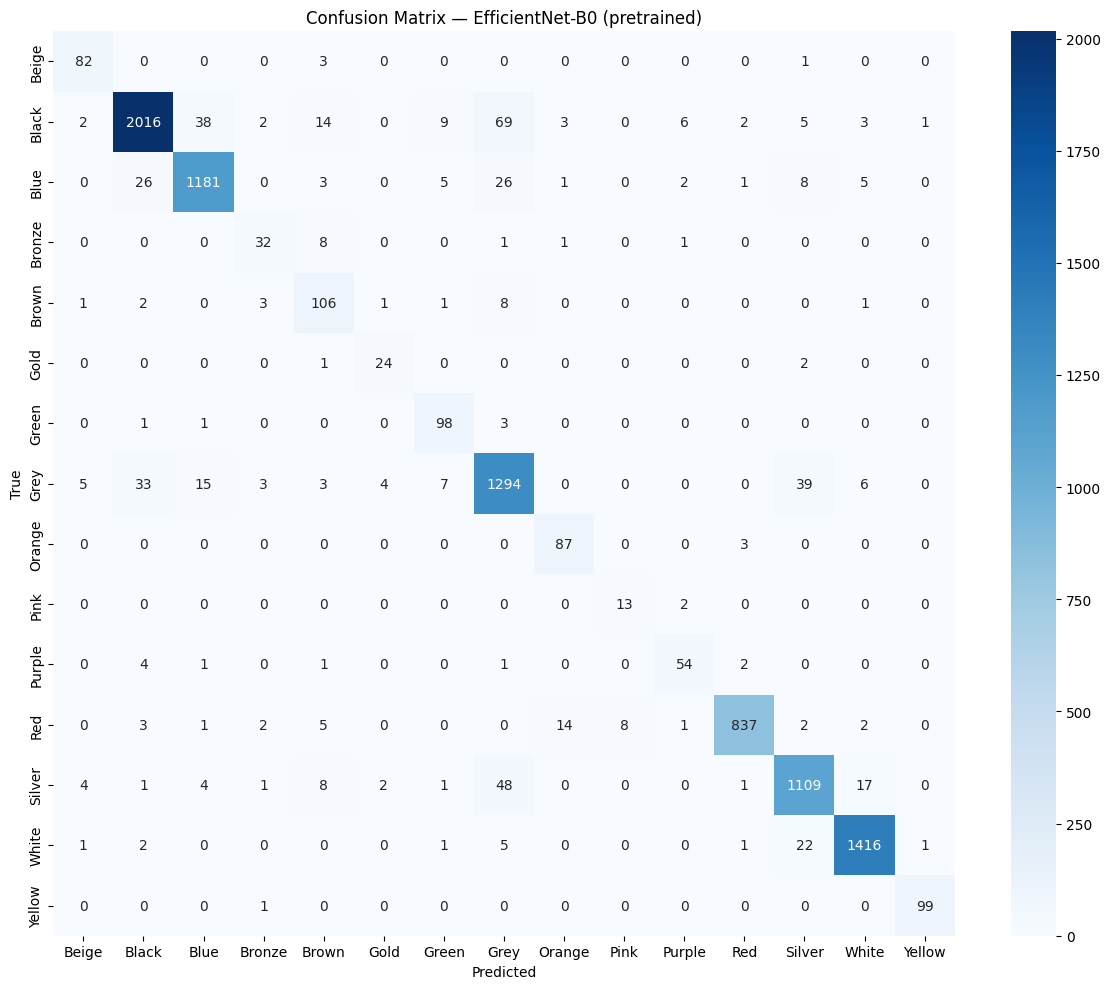

In [33]:
best_model_name = comparison.iloc[0]["Model"]
best_true = results[best_model_name]["true"]
best_pred = results[best_model_name]["pred"]

target_names = [idx_to_color[i] for i in range(num_classes)]
cm = confusion_matrix(best_true, best_pred)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

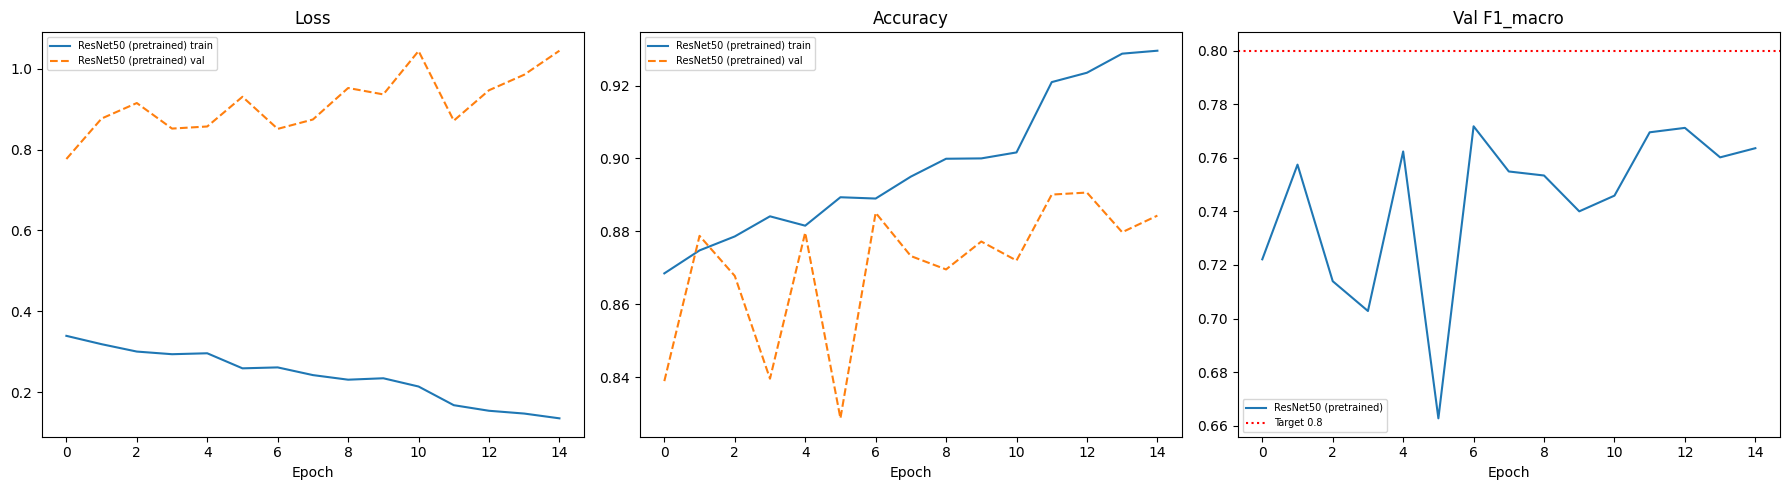

In [37]:
histories = {
    # "MyResNet18": history_custom,
    "ResNet50 (pretrained)": history_resnet50,
    # "EfficientNet-B0 (pretrained)": history_effnet,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, h in histories.items():
    axes[0].plot(h["train_loss"], label=f"{name} train")
    axes[0].plot(h["val_loss"], '--', label=f"{name} val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=7)

for name, h in histories.items():
    axes[1].plot(h["train_acc"], label=f"{name} train")
    axes[1].plot(h["val_acc"], '--', label=f"{name} val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=7)

for name, h in histories.items():
    axes[2].plot(h["val_f1"], label=name)
axes[2].set_title("Val F1_macro")
axes[2].set_xlabel("Epoch")
axes[2].axhline(y=0.8, color='r', linestyle=':', label="Target 0.8")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()